In [ ]:
!pip install kaggle

In [ ]:
#configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 58% 94.0M/163M [00:00<00:00, 939MB/s]
100% 163M/163M [00:00<00:00, 703MB/s] 


In [ ]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
!ls

data  drive  face-mask-dataset.zip  kaggle.json  sample_data


**Importing the Dependencies**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_106.jpg', 'with_mask_275.jpg', 'with_mask_933.jpg', 'with_mask_50.jpg', 'with_mask_2194.jpg']
['with_mask_2135.jpg', 'with_mask_2413.jpg', 'with_mask_938.jpg', 'with_mask_778.jpg', 'with_mask_19.jpg']


In [ ]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1768.jpg', 'without_mask_1627.jpg', 'without_mask_1909.jpg', 'without_mask_1144.jpg', 'without_mask_434.jpg']
['without_mask_2305.jpg', 'without_mask_991.jpg', 'without_mask_292.jpg', 'without_mask_717.jpg', 'without_mask_3038.jpg']


In [ ]:
print("The no.of images with mask is:", len(with_mask_files))
print("The no.of images without mask is:", len(without_mask_files))

The no.of images with mask is: 3725
The no.of images without mask is: 3828


**Creating labels for the two class of images**

*   with-mask : 1

*   without-mask : 0

In [ ]:
# create the labels

with_mask_labels = [1] * len(with_mask_files)

without_mask_labels = [0] * len(without_mask_files)

In [ ]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [ ]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [ ]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the images**

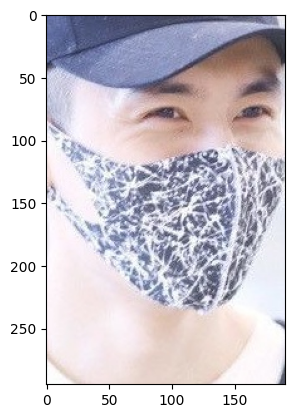

In [ ]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_951.jpg')
imgplot = plt.imshow(img)
plt.show()

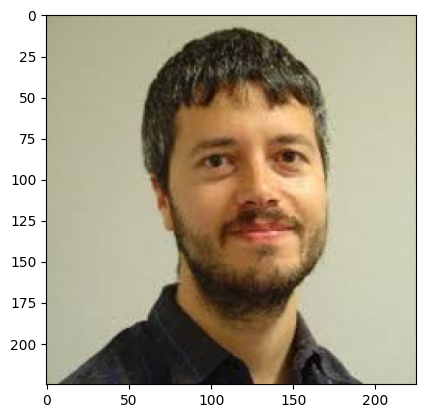

In [ ]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2257.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image** **Processing**

1.   Resize the images
2.   Converting the images to numpy arrays



In [ ]:
# convert images to numpy arrays

with_mask_path = '/content/data/with_mask/'
data = []

for img_file in with_mask_files:
  image = Image.open(with_mask_path + img_file)
  image = image.resize((128 , 128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'

for img_file in without_mask_files:
  image = Image.open(without_mask_path + img_file)
  image = image.resize((128 , 128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
type(data)

list

In [ ]:
len(data)

7553

array([[[ 28,  32,  35],
        [ 25,  29,  32],
        [ 24,  28,  31],
        ...,
        [ 74,  70,  71],
        [112, 106, 100],
        [182, 174, 164]],

       [[ 27,  30,  35],
        [ 23,  26,  31],
        [ 22,  25,  30],
        ...,
        [ 91,  87,  89],
        [112, 107, 104],
        [148, 142, 135]],

       [[ 26,  29,  36],
        [ 28,  31,  37],
        [ 20,  22,  27],
        ...,
        [ 75,  70,  75],
        [ 82,  78,  78],
        [ 86,  80,  78]],

       ...,

       [[160, 136, 118],
        [158, 134, 116],
        [159, 133, 114],
        ...,
        [212, 208, 183],
        [214, 210, 185],
        [218, 214, 189]],

       [[160, 135, 120],
        [158, 133, 118],
        [157, 133, 117],
        ...,
        [211, 206, 183],
        [213, 209, 185],
        [216, 212, 187]],

       [[161, 134, 122],
        [158, 131, 119],
        [155, 132, 118],
        ...,
        [210, 205, 184],
        [213, 209, 185],
        [216, 212, 187]]], dtype=uint8)
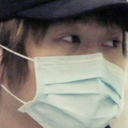

In [ ]:
data[0]

In [ ]:
data[0].shape

(128, 128, 3)

In [ ]:
# converting image list and label list to nupmy arrays

X = np.array(data)
Y = np.array(labels)

In [ ]:
type(X)
type(Y)

numpy.ndarray

In [ ]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


**Train Test Split**

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 2)

In [ ]:
print(X.shape , X_train.shape , X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [ ]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

**You can see the difference before and after scaling the data**

array([[[ 93, 124, 170],
        [ 92, 122, 167],
        [ 90, 118, 161],
        ...,
        [ 25,  34,  43],
        [ 28,  37,  46],
        [ 30,  37,  47]],

       [[ 84, 113, 158],
        [ 84, 113, 157],
        [ 84, 112, 153],
        ...,
        [ 27,  36,  46],
        [ 29,  38,  47],
        [ 29,  38,  47]],

       [[ 72, 100, 139],
        [ 73, 100, 138],
        [ 74,  98, 135],
        ...,
        [ 23,  33,  44],
        [ 23,  33,  43],
        [ 22,  32,  41]],

       ...,

       [[222, 239, 255],
        [221, 238, 254],
        [214, 231, 248],
        ...,
        [148, 146, 160],
        [148, 146, 160],
        [149, 149, 161]],

       [[220, 237, 253],
        [216, 233, 249],
        [207, 224, 242],
        ...,
        [152, 150, 164],
        [149, 148, 161],
        [147, 147, 159]],

       [[218, 236, 250],
        [217, 234, 249],
        [207, 224, 242],
        ...,
        [154, 152, 166],
        [150, 148, 162],
        [146, 145, 159]]], dtype=uint8)
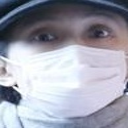

In [ ]:
X_train[0]

In [ ]:
X_train_scaled[0]

array([[[0.36470588, 0.48627451, 0.66666667],
        [0.36078431, 0.47843137, 0.65490196],
        [0.35294118, 0.4627451 , 0.63137255],
        ...,
        [0.09803922, 0.13333333, 0.16862745],
        [0.10980392, 0.14509804, 0.18039216],
        [0.11764706, 0.14509804, 0.18431373]],

       [[0.32941176, 0.44313725, 0.61960784],
        [0.32941176, 0.44313725, 0.61568627],
        [0.32941176, 0.43921569, 0.6       ],
        ...,
        [0.10588235, 0.14117647, 0.18039216],
        [0.11372549, 0.14901961, 0.18431373],
        [0.11372549, 0.14901961, 0.18431373]],

       [[0.28235294, 0.39215686, 0.54509804],
        [0.28627451, 0.39215686, 0.54117647],
        [0.29019608, 0.38431373, 0.52941176],
        ...,
        [0.09019608, 0.12941176, 0.17254902],
        [0.09019608, 0.12941176, 0.16862745],
        [0.08627451, 0.1254902 , 0.16078431]],

       ...,

       [[0.87058824, 0.9372549 , 1.        ],
        [0.86666667, 0.93333333, 0.99607843],
        [0.83921569, 0

**Building a Convolutional Neural Networks**

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32 , kernel_size = (3 , 3), activation = 'relu' , input_shape = (128 , 128 , 3)))
model.add(keras.layers.MaxPooling2D(pool_size = (2 , 2)))

model.add(keras.layers.Conv2D(64 , kernel_size = (3 , 3), activation = 'relu'))
model.add(keras.layers.MaxPooling2D(pool_size = (2 , 2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128 , activation = 'relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64 , activation = 'relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes , activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the neural network
model.compile(optimizer = 'adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['acc'])

In [ ]:
# training the neural network
history = model.fit(X_train_scaled , Y_train , validation_split = 0.1 , epochs = 5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - acc: 0.6387 - loss: 0.9676 - val_acc: 0.8711 - val_loss: 0.3084
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8709 - loss: 0.3208 - val_acc: 0.8926 - val_loss: 0.2645
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8994 - loss: 0.2537 - val_acc: 0.9041 - val_loss: 0.2343
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.9189 - loss: 0.2212 - val_acc: 0.9058 - val_loss: 0.2180
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.9291 - loss: 0.1758 - val_acc: 0.8876 - val_loss: 0.3335


**Model Evaluation**

In [ ]:
loss , accuracy = model.evaluate(X_test_scaled , Y_test)
print('Test Accuracy = ' , accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9047 - loss: 0.3140
Test Accuracy =  0.8927862048149109


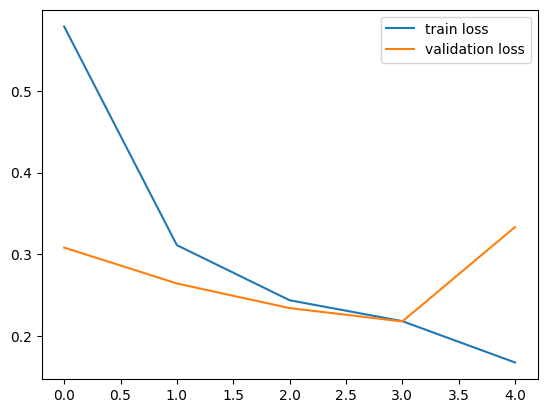

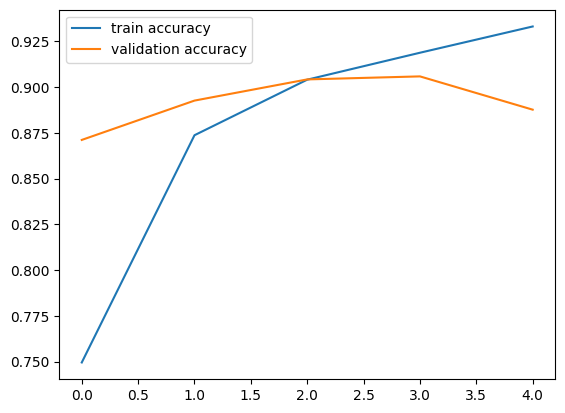

In [ ]:
h = history

# plot the loss value
plt.plot(h.history['loss'] , label = 'train loss')
plt.plot(h.history['val_loss'] , label = 'validation loss')
plt.legend()
plt.show()

# plot the accuracy values
plt.plot(h.history['acc'] , label = 'train accuracy')
plt.plot(h.history['val_acc'] , label = 'validation accuracy')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted: /content/Wear 1.webp


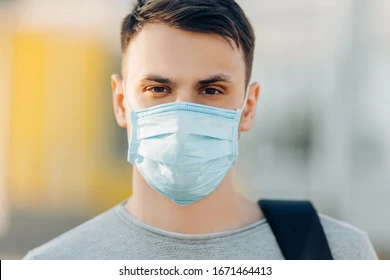

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.5834595  0.33639085]]
0
The person in the image is not wearing a mask


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

In [15]:
!git --version

git version 2.34.1


In [16]:
!git clone https://github.com/mohammadsufiyan1808/Real-Time-Face-Mask-Detection-Using-Deep-Learning-and-Computer-Vision.git

Cloning into 'Real-Time-Face-Mask-Detection-Using-Deep-Learning-and-Computer-Vision'...


In [17]:
%cd Real-Time-Face-Mask-Detection-Using-Deep-Learning-and-Computer-Vision

/content/Real-Time-Face-Mask-Detection-Using-Deep-Learning-and-Computer-Vision


In [18]:
!pwd
!ls

/content/Real-Time-Face-Mask-Detection-Using-Deep-Learning-and-Computer-Vision


In [19]:
!git status

On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [20]:
!cp /content/Real-Time-Face-Mask-Detection-Using-Deep-Learning-and-Computer-Vision.zip /content

cp: cannot stat '/content/Real-Time-Face-Mask-Detection-Using-Deep-Learning-and-Computer-Vision.zip': No such file or directory


In [21]:
!git add .

In [22]:
!git status

On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [ ]:
!ls

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
!ls

sample_data


In [6]:
!find /content/drive -type d -name "Mini Project"


find: ‘/content/drive’: No such file or directory


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!find /content/drive -type d -name "Mini Project"

In [10]:
!ls /content/drive

MyDrive


In [11]:
!ls /content/drive/MyDrive


'Colab Notebooks'	        Screenshot_20250309-200048.png
 college_ID-CARD.jpeg	        Screenshot_20250316-194220.png
"DSA by Shradha Ma'am.gsheet"  'SUFIYAN_ (1).pdf'
 Id-card-BS.jpeg	        SUFIYAN.pdf
 Marks_Sheet.jpg	        SUFIYAN_.pdf
'Mini Project.ipynb'	        SUFIYAN_RESUME.pdf


In [12]:
!cp "/content/drive/MyDrive/Mini Project.ipynb" .

In [13]:
!ls

 drive	'Mini Project.ipynb'   sample_data


In [23]:
!git add "Mini Project.ipynb"

fatal: pathspec 'Mini Project.ipynb' did not match any files


In [24]:
%cd /content/Real-Time-Face-Mask-Detection-Using-Deep-Learning-and-Computer-Vision

/content/Real-Time-Face-Mask-Detection-Using-Deep-Learning-and-Computer-Vision


In [25]:
!ls -a

.  ..  .git
